In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [2]:
BORUTA_TRIALS = 20

In [3]:
df = pd.read_csv('../nr_ic_merged.csv')

In [4]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [5]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134040>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134190>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134200>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134270>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b1342e0>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce8f0>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce960>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce9d0>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdcea40>


In [6]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [7]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134190>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134200>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134270>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b1342e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce8f0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce960>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce9d0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdcea40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [9]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp,target_encoded
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134190>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134200>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b134270>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8c9b1342e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce8f0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce960>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdce9d0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f8c9bdcea40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"


In [10]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [11]:
df_agg

,target,fp
0,"[0, 1, 1, 1, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[1, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
7202,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7203,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7204,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7205,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [12]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [14]:
import numpy as np
import scipy.stats

if not hasattr(np, 'NaN'):
    np.NaN = np.nan
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

if not hasattr(scipy.stats, 'binom_test'):
    def binom_test_wrapper(x, n=None, p=0.5, alternative='two-sided'):
        k_clean = int(x)
        n_clean = int(n) if n is not None else None

        return scipy.stats.binomtest(k=k_clean, n=n_clean, p=p, alternative=alternative).pvalue

    scipy.stats.binom_test = binom_test_wrapper

from BorutaShap import BorutaShap
import pandas as pd

feature_names = [f"Bit_{i}" for i in range(x.shape[1])]
X_df = pd.DataFrame(x, columns=feature_names)

target_names = encoder.categories_[0]

print(f"Feature Matrix Shape: {X_df.shape}")
print(f"Targets to analyze: {target_names}")

Feature Matrix Shape: (7207, 4096)
Targets to analyze: ['ar' 'era' 'erb' 'gr' 'mr' 'pr']


In [15]:
import numpy as np

for i, name in enumerate(target_names):
    n_pos = y[:, i].sum()
    n_neg = y.shape[0] - n_pos
    print(f"{name}: positives={n_pos}, negatives={n_neg}")

ar: positives=1802, negatives=5405
era: positives=2425, negatives=4782
erb: positives=1501, negatives=5706
gr: positives=1630, negatives=5577
mr: positives=781, negatives=6426
pr: positives=1368, negatives=5839



--- Zpracovávám cíl: ar ---


  0%|          | 0/20 [00:00<?, ?it/s]

100 attributes confirmed important: ['bit_2331', 'bit_2322', 'bit_2944', 'bit_1313', 'bit_3049', 'bit_3839', 'bit_928', 'bit_92', 'bit_1112', 'bit_162', 'bit_280', 'bit_1536', 'bit_621', 'bit_3184', 'bit_2049', 'bit_2', 'bit_675', 'bit_2437', 'bit_1594', 'bit_899', 'bit_2371', 'bit_1862', 'bit_242', 'bit_2855', 'bit_2793', 'bit_2362', 'bit_3449', 'bit_25', 'bit_1453', 'bit_2883', 'bit_1308', 'bit_630', 'bit_1337', 'bit_1106', 'bit_361', 'bit_3880', 'bit_2838', 'bit_3637', 'bit_350', 'bit_1980', 'bit_976', 'bit_1237', 'bit_262', 'bit_2722', 'bit_1094', 'bit_2727', 'bit_2162', 'bit_1160', 'bit_875', 'bit_2467', 'bit_3608', 'bit_3798', 'bit_1088', 'bit_3851', 'bit_5', 'bit_1582', 'bit_13', 'bit_2107', 'bit_1236', 'bit_322', 'bit_3432', 'bit_4023', 'bit_3470', 'bit_2215', 'bit_2857', 'bit_2983', 'bit_1535', 'bit_1696', 'bit_529', 'bit_3162', 'bit_439', 'bit_2281', 'bit_1998', 'bit_1458', 'bit_2067', 'bit_371', 'bit_695', 'bit_3524', 'bit_3099', 'bit_2429', 'bit_1928', 'bit_1274', 'bit_3826

<Figure size 1200x600 with 0 Axes>

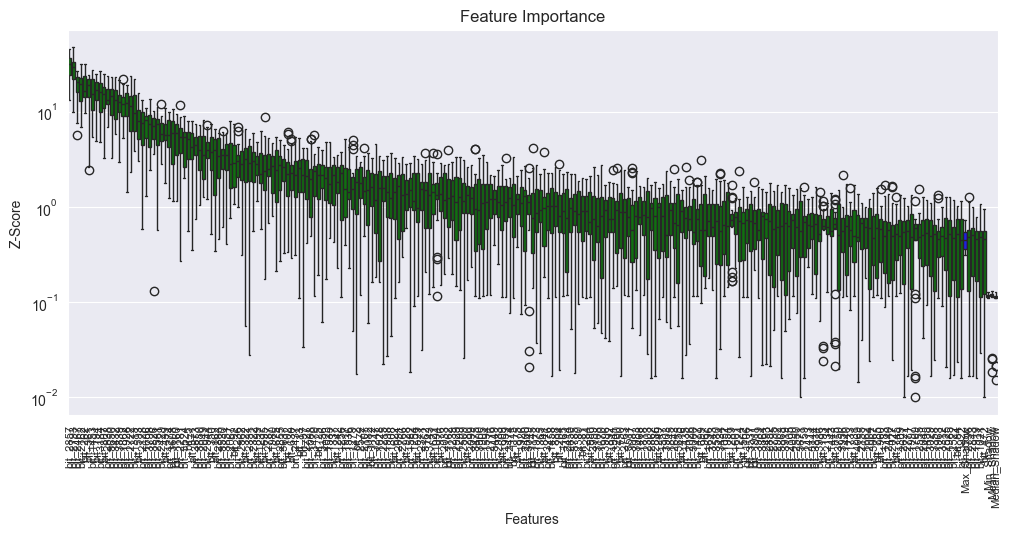

    -> cache=miss | vybrané příznaky=239

--- Zpracovávám cíl: era ---


  0%|          | 0/20 [00:00<?, ?it/s]

143 attributes confirmed important: ['bit_1326', 'bit_2300', 'bit_2944', 'bit_1480', 'bit_1313', 'bit_3839', 'bit_960', 'bit_1224', 'bit_372', 'bit_1357', 'bit_3082', 'bit_162', 'bit_280', 'bit_2698', 'bit_3184', 'bit_2', 'bit_2437', 'bit_1594', 'bit_1256', 'bit_2371', 'bit_4030', 'bit_1862', 'bit_3000', 'bit_2953', 'bit_2793', 'bit_2362', 'bit_25', 'bit_1453', 'bit_2883', 'bit_2017', 'bit_1308', 'bit_2692', 'bit_978', 'bit_3018', 'bit_630', 'bit_3414', 'bit_3880', 'bit_2838', 'bit_54', 'bit_1052', 'bit_734', 'bit_122', 'bit_350', 'bit_976', 'bit_472', 'bit_1237', 'bit_262', 'bit_1659', 'bit_2722', 'bit_3211', 'bit_1094', 'bit_1060', 'bit_3229', 'bit_2727', 'bit_2162', 'bit_4036', 'bit_1160', 'bit_1951', 'bit_3863', 'bit_3580', 'bit_2467', 'bit_1436', 'bit_3608', 'bit_1154', 'bit_1476', 'bit_2926', 'bit_3781', 'bit_1088', 'bit_3851', 'bit_1582', 'bit_13', 'bit_2932', 'bit_3475', 'bit_322', 'bit_690', 'bit_1270', 'bit_3811', 'bit_1487', 'bit_3432', 'bit_1683', 'bit_3687', 'bit_3470', 'b

<Figure size 1200x600 with 0 Axes>

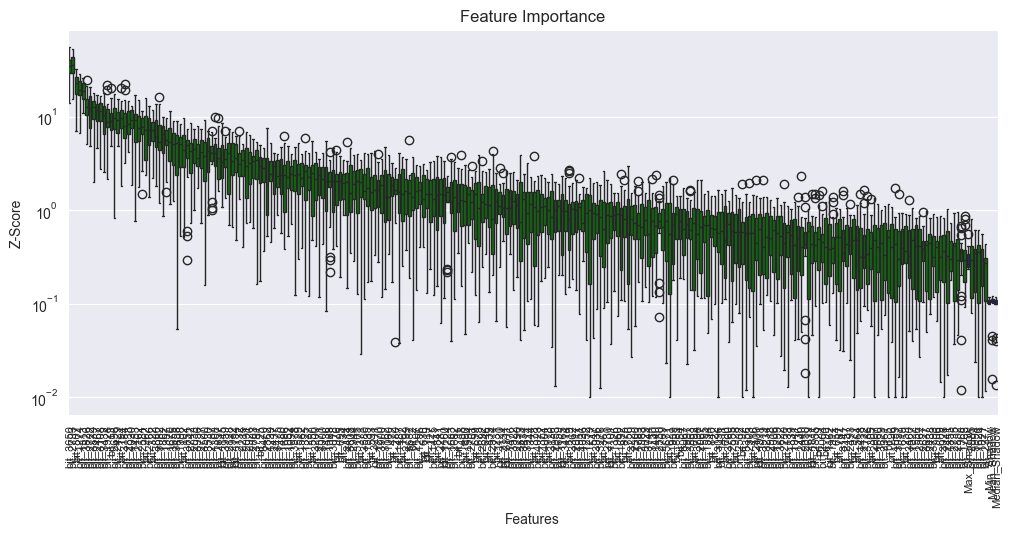

    -> cache=miss | vybrané příznaky=264

--- Zpracovávám cíl: erb ---


  0%|          | 0/20 [00:00<?, ?it/s]

106 attributes confirmed important: ['bit_2300', 'bit_2975', 'bit_1480', 'bit_656', 'bit_1313', 'bit_3839', 'bit_2007', 'bit_1917', 'bit_162', 'bit_280', 'bit_2698', 'bit_3184', 'bit_675', 'bit_193', 'bit_1443', 'bit_3057', 'bit_4030', 'bit_1862', 'bit_2855', 'bit_3665', 'bit_2793', 'bit_750', 'bit_1453', 'bit_2017', 'bit_2682', 'bit_191', 'bit_3414', 'bit_3880', 'bit_2838', 'bit_54', 'bit_680', 'bit_350', 'bit_1980', 'bit_1237', 'bit_262', 'bit_2722', 'bit_3211', 'bit_133', 'bit_3229', 'bit_2727', 'bit_2162', 'bit_4032', 'bit_4036', 'bit_1160', 'bit_875', 'bit_2467', 'bit_1344', 'bit_1436', 'bit_3608', 'bit_1154', 'bit_1692', 'bit_1165', 'bit_2997', 'bit_1088', 'bit_416', 'bit_3851', 'bit_3900', 'bit_45', 'bit_2107', 'bit_690', 'bit_699', 'bit_3811', 'bit_1487', 'bit_3432', 'bit_4023', 'bit_3470', 'bit_2215', 'bit_1309', 'bit_2857', 'bit_2983', 'bit_1535', 'bit_1325', 'bit_3655', 'bit_3162', 'bit_439', 'bit_3200', 'bit_1998', 'bit_1475', 'bit_3108', 'bit_841', 'bit_2429', 'bit_2799', 

<Figure size 1200x600 with 0 Axes>

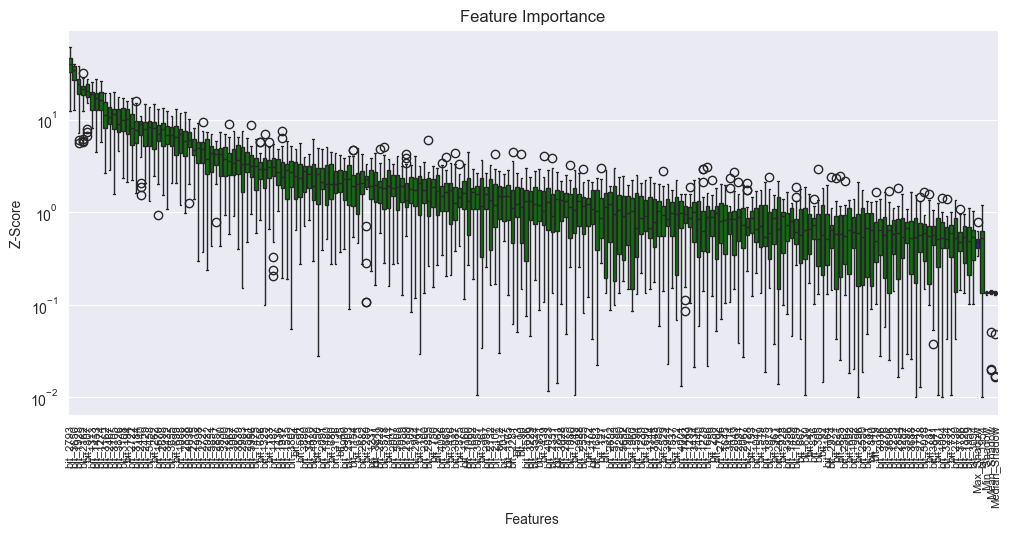

    -> cache=miss | vybrané příznaky=206

--- Zpracovávám cíl: gr ---


  0%|          | 0/20 [00:00<?, ?it/s]

145 attributes confirmed important: ['bit_2944', 'bit_1480', 'bit_1313', 'bit_378', 'bit_3839', 'bit_1224', 'bit_3232', 'bit_1421', 'bit_348', 'bit_3082', 'bit_280', 'bit_1536', 'bit_621', 'bit_3184', 'bit_635', 'bit_2049', 'bit_2284', 'bit_1147', 'bit_1594', 'bit_4006', 'bit_3057', 'bit_1862', 'bit_2793', 'bit_2362', 'bit_375', 'bit_1453', 'bit_1941', 'bit_2230', 'bit_2017', 'bit_1687', 'bit_2682', 'bit_3919', 'bit_1021', 'bit_630', 'bit_3770', 'bit_2854', 'bit_3744', 'bit_361', 'bit_3880', 'bit_2838', 'bit_2936', 'bit_1257', 'bit_1418', 'bit_350', 'bit_3150', 'bit_1435', 'bit_1237', 'bit_3349', 'bit_3786', 'bit_262', 'bit_3211', 'bit_2727', 'bit_1440', 'bit_1160', 'bit_1436', 'bit_3608', 'bit_1154', 'bit_1165', 'bit_2926', 'bit_1088', 'bit_1252', 'bit_13', 'bit_3900', 'bit_2932', 'bit_45', 'bit_4069', 'bit_2107', 'bit_1236', 'bit_1270', 'bit_699', 'bit_3432', 'bit_1553', 'bit_3387', 'bit_2857', 'bit_2493', 'bit_1219', 'bit_2983', 'bit_2290', 'bit_1535', 'bit_2021', 'bit_2567', 'bit_3

<Figure size 1200x600 with 0 Axes>

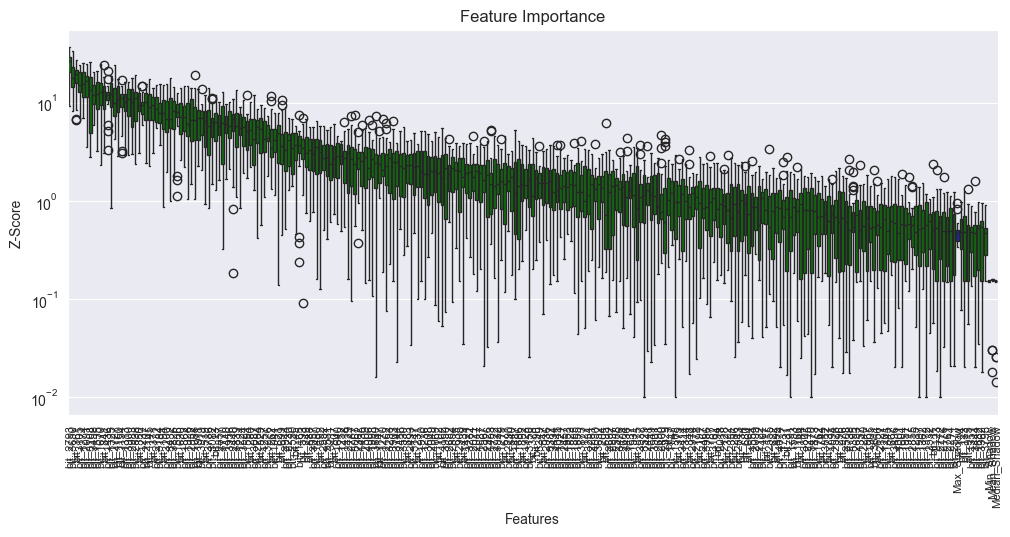

    -> cache=miss | vybrané příznaky=263

--- Zpracovávám cíl: mr ---


  0%|          | 0/20 [00:00<?, ?it/s]

107 attributes confirmed important: ['bit_3330', 'bit_2331', 'bit_2127', 'bit_656', 'bit_3079', 'bit_1313', 'bit_3839', 'bit_286', 'bit_1917', 'bit_1099', 'bit_3756', 'bit_1357', 'bit_3699', 'bit_3219', 'bit_2698', 'bit_732', 'bit_1536', 'bit_1152', 'bit_3629', 'bit_2049', 'bit_2284', 'bit_2377', 'bit_1594', 'bit_4006', 'bit_1365', 'bit_4030', 'bit_2793', 'bit_2362', 'bit_929', 'bit_3822', 'bit_1338', 'bit_993', 'bit_630', 'bit_991', 'bit_3770', 'bit_456', 'bit_361', 'bit_608', 'bit_3880', 'bit_350', 'bit_1435', 'bit_1237', 'bit_262', 'bit_1060', 'bit_2727', 'bit_2162', 'bit_2467', 'bit_3608', 'bit_1154', 'bit_944', 'bit_13', 'bit_2107', 'bit_322', 'bit_690', 'bit_699', 'bit_1905', 'bit_1487', 'bit_1101', 'bit_2857', 'bit_748', 'bit_3655', 'bit_2518', 'bit_3162', 'bit_3200', 'bit_371', 'bit_3108', 'bit_3524', 'bit_841', 'bit_2303', 'bit_1755', 'bit_2429', 'bit_1646', 'bit_609', 'bit_1928', 'bit_3782', 'bit_132', 'bit_873', 'bit_1274', 'bit_140', 'bit_971', 'bit_3458', 'bit_3826', 'bit_

<Figure size 1200x600 with 0 Axes>

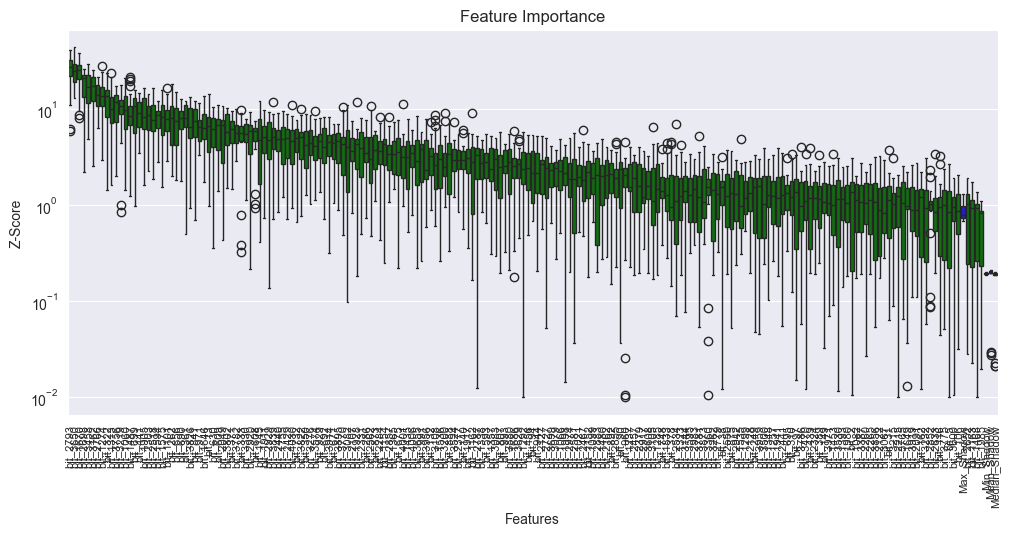

    -> cache=miss | vybrané příznaky=197

--- Zpracovávám cíl: pr ---


  0%|          | 0/20 [00:00<?, ?it/s]

99 attributes confirmed important: ['bit_2944', 'bit_2757', 'bit_1480', 'bit_378', 'bit_1313', 'bit_3839', 'bit_928', 'bit_960', 'bit_372', 'bit_1917', 'bit_1357', 'bit_1973', 'bit_785', 'bit_3184', 'bit_2738', 'bit_1594', 'bit_197', 'bit_2122', 'bit_4030', 'bit_216', 'bit_746', 'bit_2855', 'bit_2413', 'bit_2793', 'bit_2362', 'bit_127', 'bit_2438', 'bit_2017', 'bit_2682', 'bit_809', 'bit_36', 'bit_991', 'bit_3414', 'bit_3880', 'bit_2838', 'bit_1980', 'bit_2722', 'bit_3211', 'bit_3144', 'bit_2534', 'bit_4032', 'bit_1160', 'bit_3436', 'bit_1951', 'bit_1436', 'bit_852', 'bit_1692', 'bit_1165', 'bit_815', 'bit_2926', 'bit_3851', 'bit_13', 'bit_2107', 'bit_322', 'bit_699', 'bit_2256', 'bit_3811', 'bit_3432', 'bit_1683', 'bit_296', 'bit_2857', 'bit_2730', 'bit_564', 'bit_1638', 'bit_2983', 'bit_2290', 'bit_1535', 'bit_3655', 'bit_3162', 'bit_439', 'bit_1382', 'bit_253', 'bit_2281', 'bit_1998', 'bit_1475', 'bit_2414', 'bit_3108', 'bit_695', 'bit_1626', 'bit_3397', 'bit_841', 'bit_2429', 'bit_

<Figure size 1200x600 with 0 Axes>

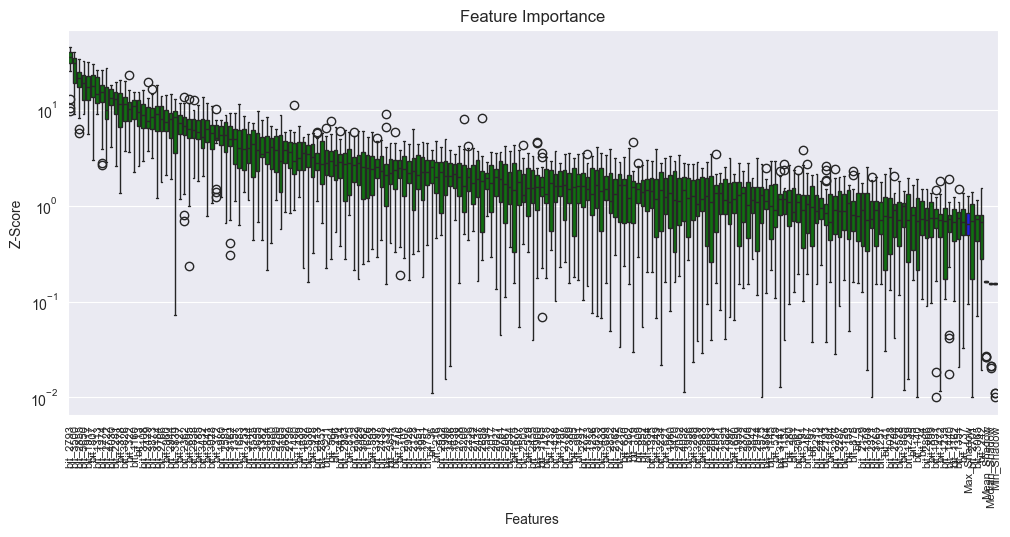

    -> cache=miss | vybrané příznaky=199

Hotovo! Matice Z-skóre uložena do 'boruta_zscores_matrix_rf.csv'
Uloženy SVG grafy top-N: 'boruta_top_20_bity_tepelna_mapa_zskore.svg' a 'boruta_top_20_bity_sloupcovy_graf_mean_abs_zskore.svg'


In [16]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from BorutaShap import BorutaShap
from xgboost import XGBClassifier

# --- 0. CHECKPOINTING HELPERS (same scheme as motif viz script) ---
repo_root = Path.cwd().resolve()
# Notebook is in qsar/random-forest/, so repo root is two parents up
if repo_root.name == 'random-forest':
    repo_root = repo_root.parent.parent
elif repo_root.name == 'qsar':
    repo_root = repo_root.parent

qspr_dir = repo_root / 'qspr'
if str(qspr_dir) not in sys.path:
    sys.path.insert(0, str(qspr_dir))

from qspr_common import file_signature, load_pickle_cache, save_pickle_cache

CACHE_VERSION = 1

# Configure cache/output dirs similar to motif visualization
cache_dir = repo_root / 'qsar' / 'cache' / 'random-forest-motifs'
cache_dir.mkdir(parents=True, exist_ok=True)
out_dir = Path.cwd()  # keep outputs beside the notebook by default

# --- 1. SETUP ---
# Assumptions: 'x', 'y', 'target_names', and 'BORUTA_TRIALS' are already defined
feature_names = [f"bit_{i}" for i in range(x.shape[1])]
X_boruta = pd.DataFrame(x, columns=feature_names)

# Dictionary to store the final list of "kept" features for each target
selected_features_per_target = {}

# RF Configuration
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)

# We'll collect z-scores per target -> DataFrame saved to CSV
zscore_results = []

# Data signature used for cache invalidation
data_path = (Path.cwd().parent / 'nr_ic_merged.csv').resolve()
data_sig = file_signature(data_path) if data_path.exists() else {"path": str(data_path), "size": None, "mtime_ns": None}

# --- 2. LOOP PER TARGET ---
for i, target_name in enumerate(target_names):
    print(f"\n--- Zpracovávám cíl: {target_name} ---")

    y_target = pd.Series(y[:, i], name=str(target_name))

    # Cache key/metadata (matches motif visualization approach)
    safe_name = str(target_name).replace('/', '_').replace(' ', '_')
    boruta_cache_path = cache_dir / f"boruta_target_{safe_name}.pkl"
    boruta_cache_meta = {
        "version": CACHE_VERSION,
        "kind": "qsar_boruta_target_scores",
        "target_name": str(target_name),
        "data": data_sig,
        "n_bits": int(x.shape[1]),
        "random_seed": 42,
        "boruta_n_trials": int(BORUTA_TRIALS),
        "model": {
            "type": "RandomForestClassifier",
            "n_estimators": int(getattr(rf_model, 'n_estimators', 0)),
            "max_depth": int(getattr(rf_model, 'max_depth', 0) or 0),
            "class_weight": str(getattr(rf_model, 'class_weight', None)),
        },
    }

    cached = load_pickle_cache(boruta_cache_path, boruta_cache_meta)

    if cached is None:
        # Initialize BorutaShap
        selector = BorutaShap(
            model=rf_model,
            importance_measure='shap',
            classification=True,
        )

        try:
            selector.fit(
                X=X_boruta,
                y=y_target,
                n_trials=BORUTA_TRIALS,
                sample=False,
                verbose=True,
            )

            mean_z_scores = selector.history_x.mean(axis=0)
            mean_z_scores.name = str(target_name)

            # Store the selected features list for downstream tasks
            selector.TentativeRoughFix()
            subset = selector.Subset()
            selected_features = subset.columns.tolist()

            # Save plot (accepted features) as SVG
            print(f"Generuji graf pro {target_name}...")
            plt.figure(figsize=(12, 6))
            selector.plot(which_features='accepted', figsize=(12, 5))
            plt.title(f"BorutaShap důležitost: {target_name}")
            plt.tight_layout()
            plot_path = out_dir / f"boruta_plot_{safe_name}.svg"
            plt.savefig(plot_path, format='svg')
            plt.close()

            save_pickle_cache(
                boruta_cache_path,
                boruta_cache_meta,
                {
                    "mean_z_scores": mean_z_scores,
                    "selected_features": selected_features,
                    "accepted": [str(v) for v in getattr(selector, 'accepted', [])],
                    "tentative": [str(v) for v in getattr(selector, 'tentative', [])],
                    "rejected": [str(v) for v in getattr(selector, 'rejected', [])],
                    "plot_path": str(plot_path),
                },
            )
            cache_status = 'miss'

        except Exception as e:
            print(f"    -> Selhalo pro {target_name}: {e}")
            continue

    else:
        mean_z_scores = cached["mean_z_scores"]
        selected_features = cached.get("selected_features", [])
        cache_status = 'hit'

    # Bookkeeping for exports
    zscore_results.append(mean_z_scores)
    selected_features_per_target[target_name] = list(selected_features)

    print(f"    -> cache={cache_status} | vybrané příznaky={len(selected_features)}")

# --- 3. EXPORT Z-SCORES MATRIX ---
final_zscore_df = pd.DataFrame(zscore_results).fillna(0)
final_zscore_df.to_csv('boruta_zscores_matrix_rf.csv', index=True)
print("\nHotovo! Matice Z-skóre uložena do 'boruta_zscores_matrix_rf.csv'")

# --- 4. TOP-N BITS VISUALIZATION (like basic SHAP top-N plots; uses z-scores) ---
TOP_N = 20

# Use absolute z-score to rank
z_abs = final_zscore_df.abs()
mean_abs = z_abs.mean(axis=0).sort_values(ascending=False)

if len(mean_abs) == 0:
    raise RuntimeError('Nebyla nalezena žádná Z-skóre pro vykreslení.')

top_bits = mean_abs.head(TOP_N).index.tolist()
plot_df = final_zscore_df[top_bits]

# Heatmap: targets x bits
plt.figure(figsize=(max(10, TOP_N * 0.45), max(6, 0.35 * len(plot_df))))
row_order = plot_df.abs().sum(axis=1).sort_values(ascending=False).index
plot_df_sorted = plot_df.loc[row_order]

im = plt.imshow(plot_df_sorted.values, aspect='auto', cmap='coolwarm')
plt.colorbar(im, label='Průměrné Z-skóre (BorutaShap)')
plt.yticks(np.arange(plot_df_sorted.shape[0]), plot_df_sorted.index)
plt.xticks(np.arange(len(top_bits)), top_bits, rotation=90)
plt.title(f'Nejlepších {TOP_N} bitů podle průměru |Z| napříč cíli (BorutaShap)')
plt.tight_layout()
plt.savefig(out_dir / f'boruta_top_{TOP_N}_bity_tepelna_mapa_zskore.svg', format='svg')
plt.close()

# Bar plot: global mean(|z|)
plt.figure(figsize=(max(10, TOP_N * 0.5), 5))
plt.bar(range(len(top_bits)), mean_abs.loc[top_bits].values)
plt.xticks(range(len(top_bits)), top_bits, rotation=90)
plt.ylabel('Průměr(|Z|) napříč cíli')
plt.title(f'Nejlepších {TOP_N} bitů podle průměru |Z| (BorutaShap)')
plt.tight_layout()
plt.savefig(out_dir / f'boruta_top_{TOP_N}_bity_sloupcovy_graf_mean_abs_zskore.svg', format='svg')
plt.close()

print(
    f"Uloženy SVG grafy top-N: "
    f"'boruta_top_{TOP_N}_bity_tepelna_mapa_zskore.svg' a "
    f"'boruta_top_{TOP_N}_bity_sloupcovy_graf_mean_abs_zskore.svg'"
)
